# 05 — Recommendation Strategies & Thompson Sampling

**Project:** MARS — Multi-Agent Recommender System  
**Agent:** RecommendationAgent  
**Purpose:** Evaluate 3 strategies, Thompson Sampling dynamics,
LambdaMART feature importance, and Precision/Recall@K curves.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 12, "figure.figsize": (8, 5),
    "savefig.bbox": "tight",
})

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

import logging
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Initialise Agents

In [2]:
from data.loader import EdNetLoader
from agents.kg_agent import KnowledgeGraphAgent
from agents.diagnostic_agent import DiagnosticAgent
from agents.recommendation_agent import (
    RecommendationAgent, DEFAULT_STRATEGY_PRIORS, LAMBDAMART_FEATURES,
)

loader = EdNetLoader(data_dir="../data/raw")
questions = loader.load_questions()
lectures = loader.load_lectures()
interactions = loader.load_interactions(sample_users=500)
print(f"Interactions: {len(interactions):,} ({interactions['user_id'].nunique()} users)")

# IMPORTANT: chronological train/test split to avoid data leakage
interactions = interactions.sort_values("timestamp")
split_idx = int(len(interactions) * 0.70)
train_df = interactions.iloc[:split_idx]
test_df = interactions.iloc[split_idx:]
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

# Build KG — use ONLY train data to avoid information leakage
kg = KnowledgeGraphAgent()
kg.build_graph(questions, lectures)
kg.update_difficulties(train_df)
kg.build_prerequisites(train_df)

# Calibrate IRT
diag = DiagnosticAgent()
irt_params = diag.calibrate_from_interactions(train_df, min_answers_per_q=5)

faiss.loader | Loading faiss with AVX2 support.


faiss.loader | Successfully loaded faiss with AVX2 support.


data.loader | Loading questions from ..\data\raw\questions.csv


data.loader | Loaded 13169 questions, 189 unique tags


data.loader | Loading lectures from ..\data\raw\lectures.csv


...

mars.agent.diagnostic | Building response matrix: 821 questions, 348 users


2026-04-02 17:47:39 | mars.agent.diagnostic          | INFO    | Calibrating IRT 3PL: 348 students x 821 items


mars.agent.diagnostic | Calibrating IRT 3PL: 348 students x 821 items


2026-04-02 17:47:39 | mars.agent.diagnostic          | INFO    | IRT calibrated: b=[-3.00, 3.00], a=[0.20, 1.00], c=0.25


mars.agent.diagnostic | IRT calibrated: b=[-3.00, 3.00], a=[0.20, 1.00], c=0.25


In [3]:
# Initialise recommendation agent
rec_agent = RecommendationAgent()
rec_agent.build_content_index(lectures, questions)
rec_agent.train_collaborative(interactions)
rec_agent._kg_agent = kg

print("Recommendation agent initialised.")
print(f"  Content index: {rec_agent._faiss_index.ntotal} items")
print(f"  CF factors: users={len(rec_agent._als_user_map)}, tags={len(rec_agent._als_tag_map)}")

2026-04-02 17:47:41 | mars.agent.recommendation      | INFO    | Loading all-MiniLM-L6-v2 for content-based encoding ...


mars.agent.recommendation | Loading all-MiniLM-L6-v2 for content-based encoding ...


sentence_transformers.SentenceTransformer | Use pytorch device_name: cpu


sentence_transformers.SentenceTransformer | Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

2026-04-02 17:48:11 | mars.agent.recommendation      | INFO    | FAISS index built: 3021 items, dim=384


mars.agent.recommendation | FAISS index built: 3021 items, dim=384


2026-04-02 17:48:17 | mars.agent.recommendation      | INFO    | Collaborative model trained: 500 users × 185 tags, 64 factors


mars.agent.recommendation | Collaborative model trained: 500 users × 185 tags, 64 factors


Recommendation agent initialised.
  Content index: 3021 items
  CF factors: users=500, tags=185


## 2. Thompson Sampling Dynamics

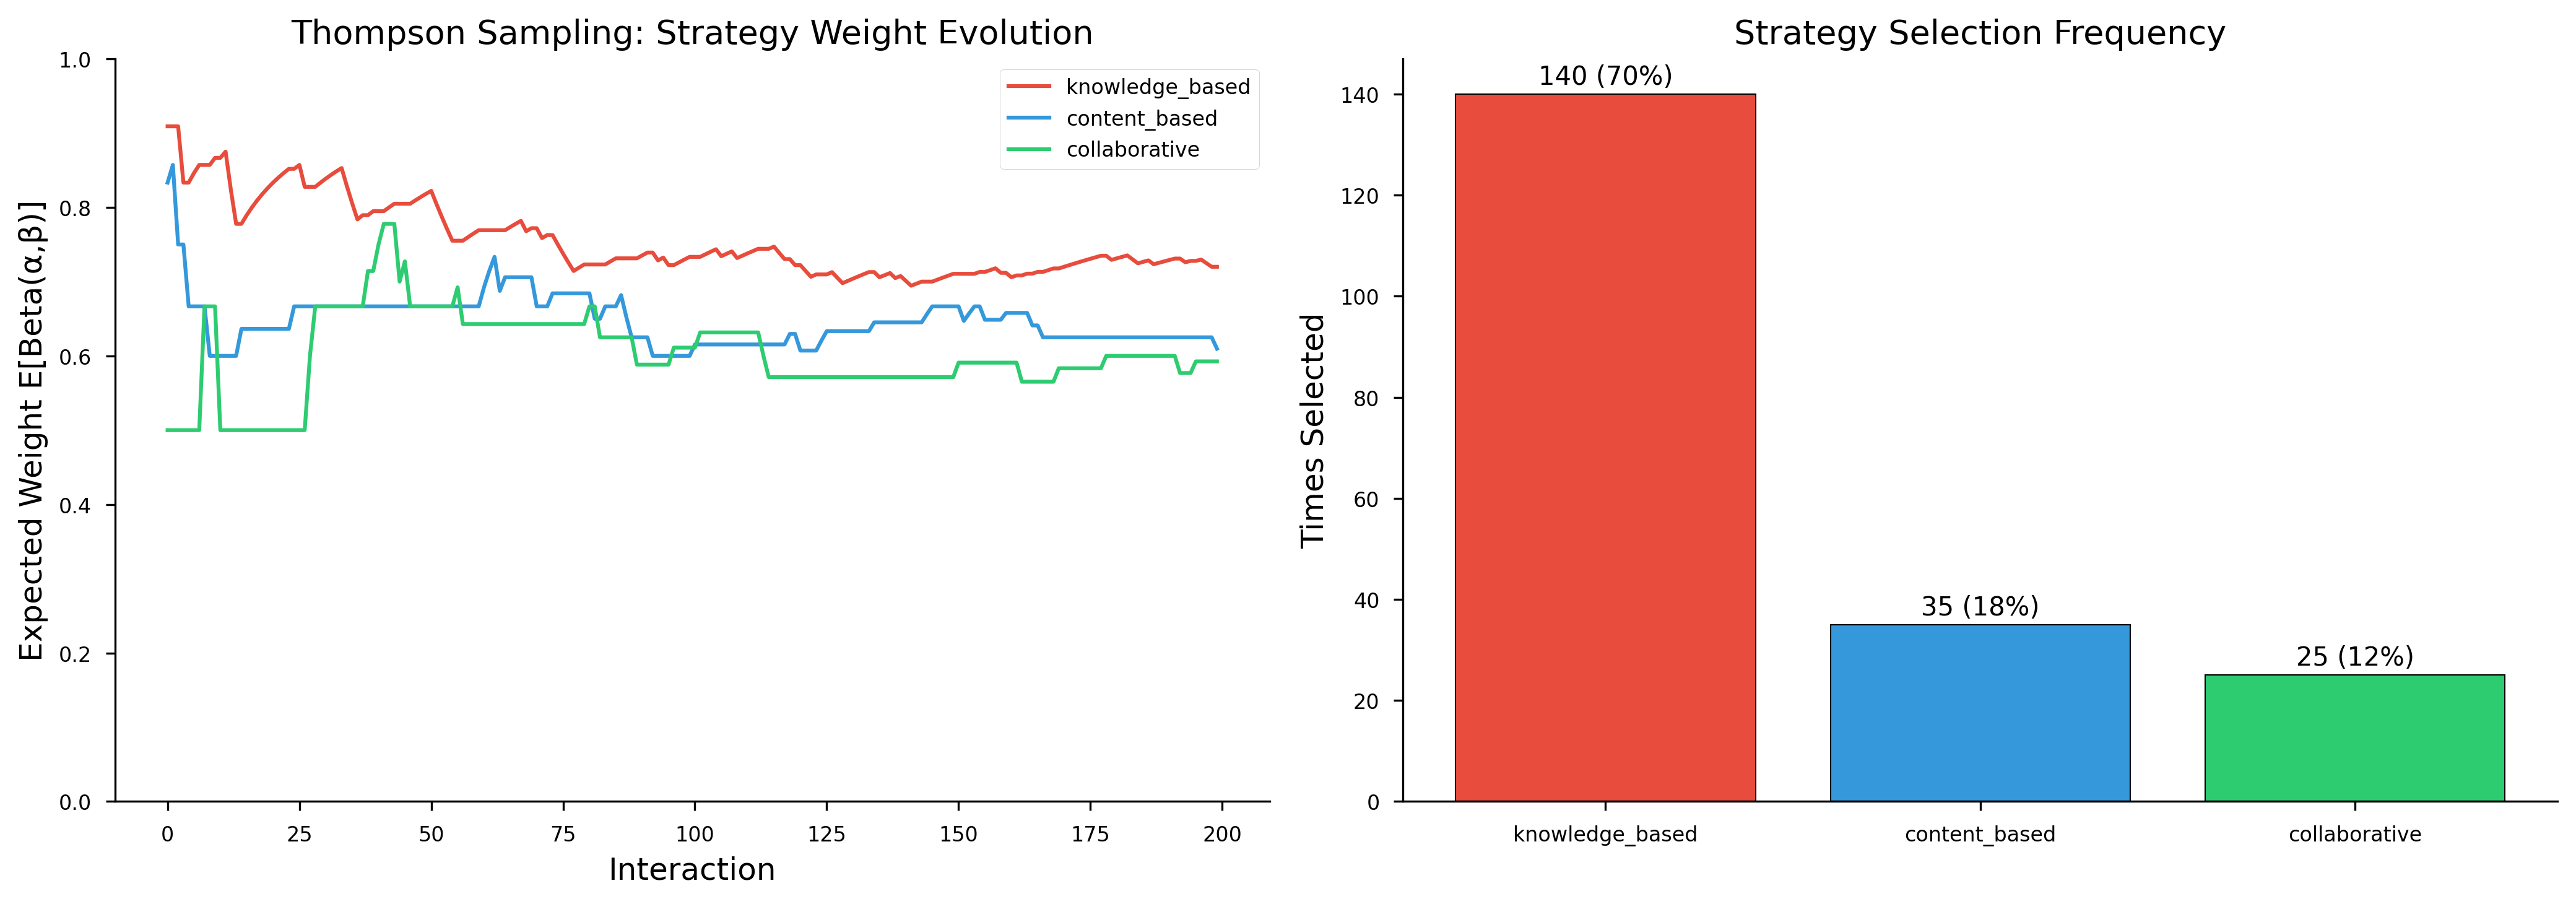

In [4]:
# Simulate Thompson Sampling over 200 interactions
np.random.seed(42)
n_steps = 200
strategies = ["knowledge_based", "content_based", "collaborative"]
ts_history = {s: [] for s in strategies}
selection_history = []

sim_user = "ts_sim_user"

for step in range(n_steps):
    # Record weights
    weights = rec_agent.get_ts_weights(sim_user)
    for s in strategies:
        ts_history[s].append(weights.get(s, 0))

    # Select strategy
    chosen = rec_agent.select_strategy(sim_user, n_interactions=50)
    selection_history.append(chosen)

    # Simulate reward based on strategy
    # KB has 70% success, CB 50%, CF 60%
    reward_probs = {"knowledge_based": 0.7, "content_based": 0.5, "collaborative": 0.6}
    reward = float(np.random.random() < reward_probs[chosen])
    rec_agent.update_reward(sim_user, chosen, reward)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight evolution
colors_ts = {"knowledge_based": "#e74c3c", "content_based": "#3498db", "collaborative": "#2ecc71"}
for s in strategies:
    axes[0].plot(ts_history[s], color=colors_ts[s], linewidth=1.5, label=s)
axes[0].set_xlabel("Interaction")
axes[0].set_ylabel("Expected Weight E[Beta(α,β)]")
axes[0].set_title("Thompson Sampling: Strategy Weight Evolution")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Selection frequency
sel_counts = pd.Series(selection_history).value_counts()
axes[1].bar(sel_counts.index, sel_counts.values,
            color=[colors_ts[s] for s in sel_counts.index],
            edgecolor="black", linewidth=0.5)
for i, (s, c) in enumerate(sel_counts.items()):
    axes[1].text(i, c + 2, f"{c} ({c/n_steps*100:.0f}%)", ha="center", fontsize=10)
axes[1].set_ylabel("Times Selected")
axes[1].set_title("Strategy Selection Frequency")

for ax in axes:
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_thompson_sampling.png")
plt.show()

## 3. Strategy Comparison (NDCG@5)

2026-04-02 17:48:20 | mars.agent.knowledge_graph     | INFO    | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


mars.agent.knowledge_graph | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00,  9.99it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

mars.agent.knowledge_graph | Cold-start for u303849: 6 mastered, 3 gaps, 194 recommendations


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 34.04it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 36.74it/s]

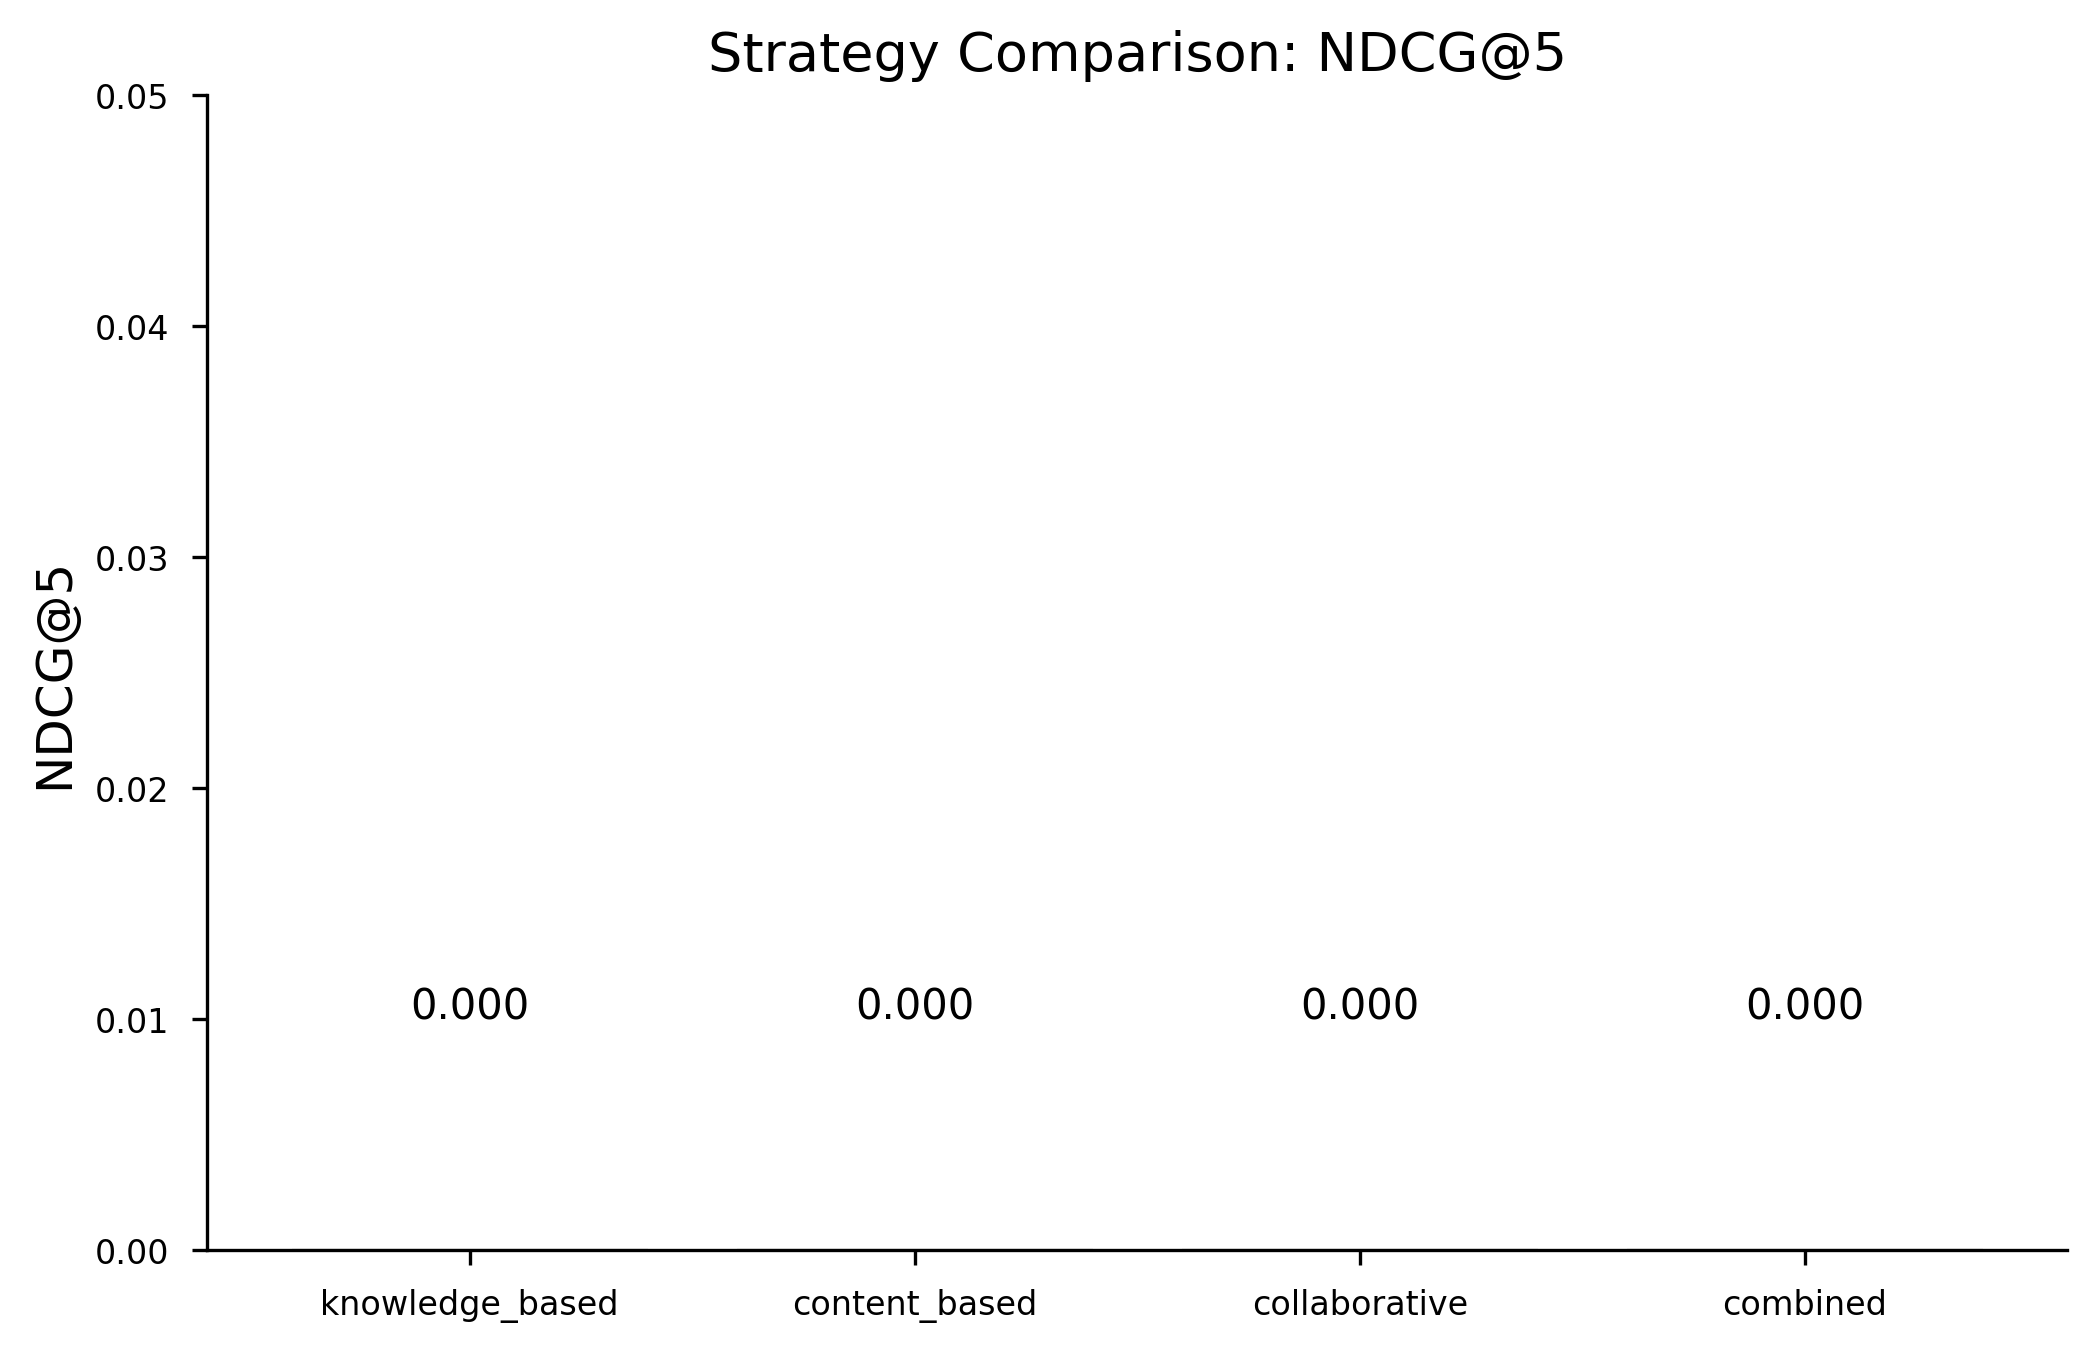

  knowledge_based     : NDCG@5 = 0.0000 +/- 0.0000
  content_based       : NDCG@5 = 0.0000 +/- 0.0000
  collaborative       : NDCG@5 = 0.0000 +/- 0.0000
  combined            : NDCG@5 = 0.0000 +/- 0.0000


In [5]:
# Evaluate each strategy separately on sample users
sample_users = interactions["user_id"].unique()[:50]

strategy_ndcgs = {s: [] for s in strategies + ["combined"]}

for uid in sample_users:
    user_df = interactions[interactions["user_id"] == uid]
    if len(user_df) < 5:
        continue

    # Ground truth: tags the user actually practised
    gt_questions = set(user_df["question_id"].astype(str).tolist())

    # Get cold-start profile from KG
    diag_resp = [{"question_id": r["question_id"], "correct": bool(r["correct"])}
                 for _, r in user_df.head(5).iterrows()]
    kg_profile = kg.handle_cold_start(user_id=str(uid), diagnostic={"responses": diag_resp})

    # Knowledge-based
    kb_recs = rec_agent.get_knowledge_based(str(uid), kg_profile=kg_profile, n=5)
    kb_ids = [r.item_id for r in kb_recs]

    # Content-based
    cb_recs = rec_agent.get_content_based(str(uid), gap_tags=kg_profile.get("gap_tags", []), n=5)
    cb_ids = [r.item_id for r in cb_recs]

    # Collaborative
    cf_recs = rec_agent.get_collaborative(str(uid), n=5)
    cf_ids = [r.item_id for r in cf_recs]

    # Combined
    combined = rec_agent.recommend(str(uid), kg_profile=kg_profile, n=5)
    comb_ids = [r["item_id"] for r in combined.get("items", [])]

    # NDCG@5 (binary relevance: did user interact with this item?)
    def ndcg_at_k(rec_ids, gt, k=5):
        dcg = sum(1.0/np.log2(i+2) for i, rid in enumerate(rec_ids[:k]) if rid in gt)
        ideal = sum(1.0/np.log2(i+2) for i in range(min(len(gt), k)))
        return dcg / ideal if ideal > 0 else 0.0

    strategy_ndcgs["knowledge_based"].append(ndcg_at_k(kb_ids, gt_questions))
    strategy_ndcgs["content_based"].append(ndcg_at_k(cb_ids, gt_questions))
    strategy_ndcgs["collaborative"].append(ndcg_at_k(cf_ids, gt_questions))
    strategy_ndcgs["combined"].append(ndcg_at_k(comb_ids, gt_questions))

fig, ax = plt.subplots(figsize=(8, 5))
means = {s: np.mean(v) if v else 0 for s, v in strategy_ndcgs.items()}
stds = {s: np.std(v) if v else 0 for s, v in strategy_ndcgs.items()}

bar_colors = ["#e74c3c", "#3498db", "#2ecc71", "#8e44ad"]
bars = ax.bar(means.keys(), means.values(), yerr=stds.values(),
              color=bar_colors, edgecolor="black", linewidth=0.5, capsize=3)
for bar, val in zip(bars, means.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=10)
ax.set_ylabel("NDCG@5")
ax.set_title("Strategy Comparison: NDCG@5")
ax.set_ylim(0, max(means.values()) * 1.3 + 0.05)
sns.despine()

fig.savefig(RESULTS_DIR / "fig_strategy_comparison.png")
plt.show()

for s, m in means.items():
    print(f"  {s:20s}: NDCG@5 = {m:.4f} +/- {stds[s]:.4f}")

## 4. Precision@K and Recall@K Curves

2026-04-02 17:48:32 | mars.agent.knowledge_graph     | INFO    | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


mars.agent.knowledge_graph | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 21.35it/s]


2026-04-02 17:48:32 | mars.agent.knowledge_graph     | INFO    | Cold-start for u249828: 5 mastered, 6 gaps, 291 recommendations


...

Batches: 100%|██████████| 1/1 [00:00<00:00, 99.78it/s]


2026-04-02 17:48:34 | mars.agent.knowledge_graph     | INFO    | Cold-start for u303849: 6 mastered, 3 gaps, 194 recommendations


mars.agent.knowledge_graph | Cold-start for u303849: 6 mastered, 3 gaps, 194 recommendations


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 117.32it/s]

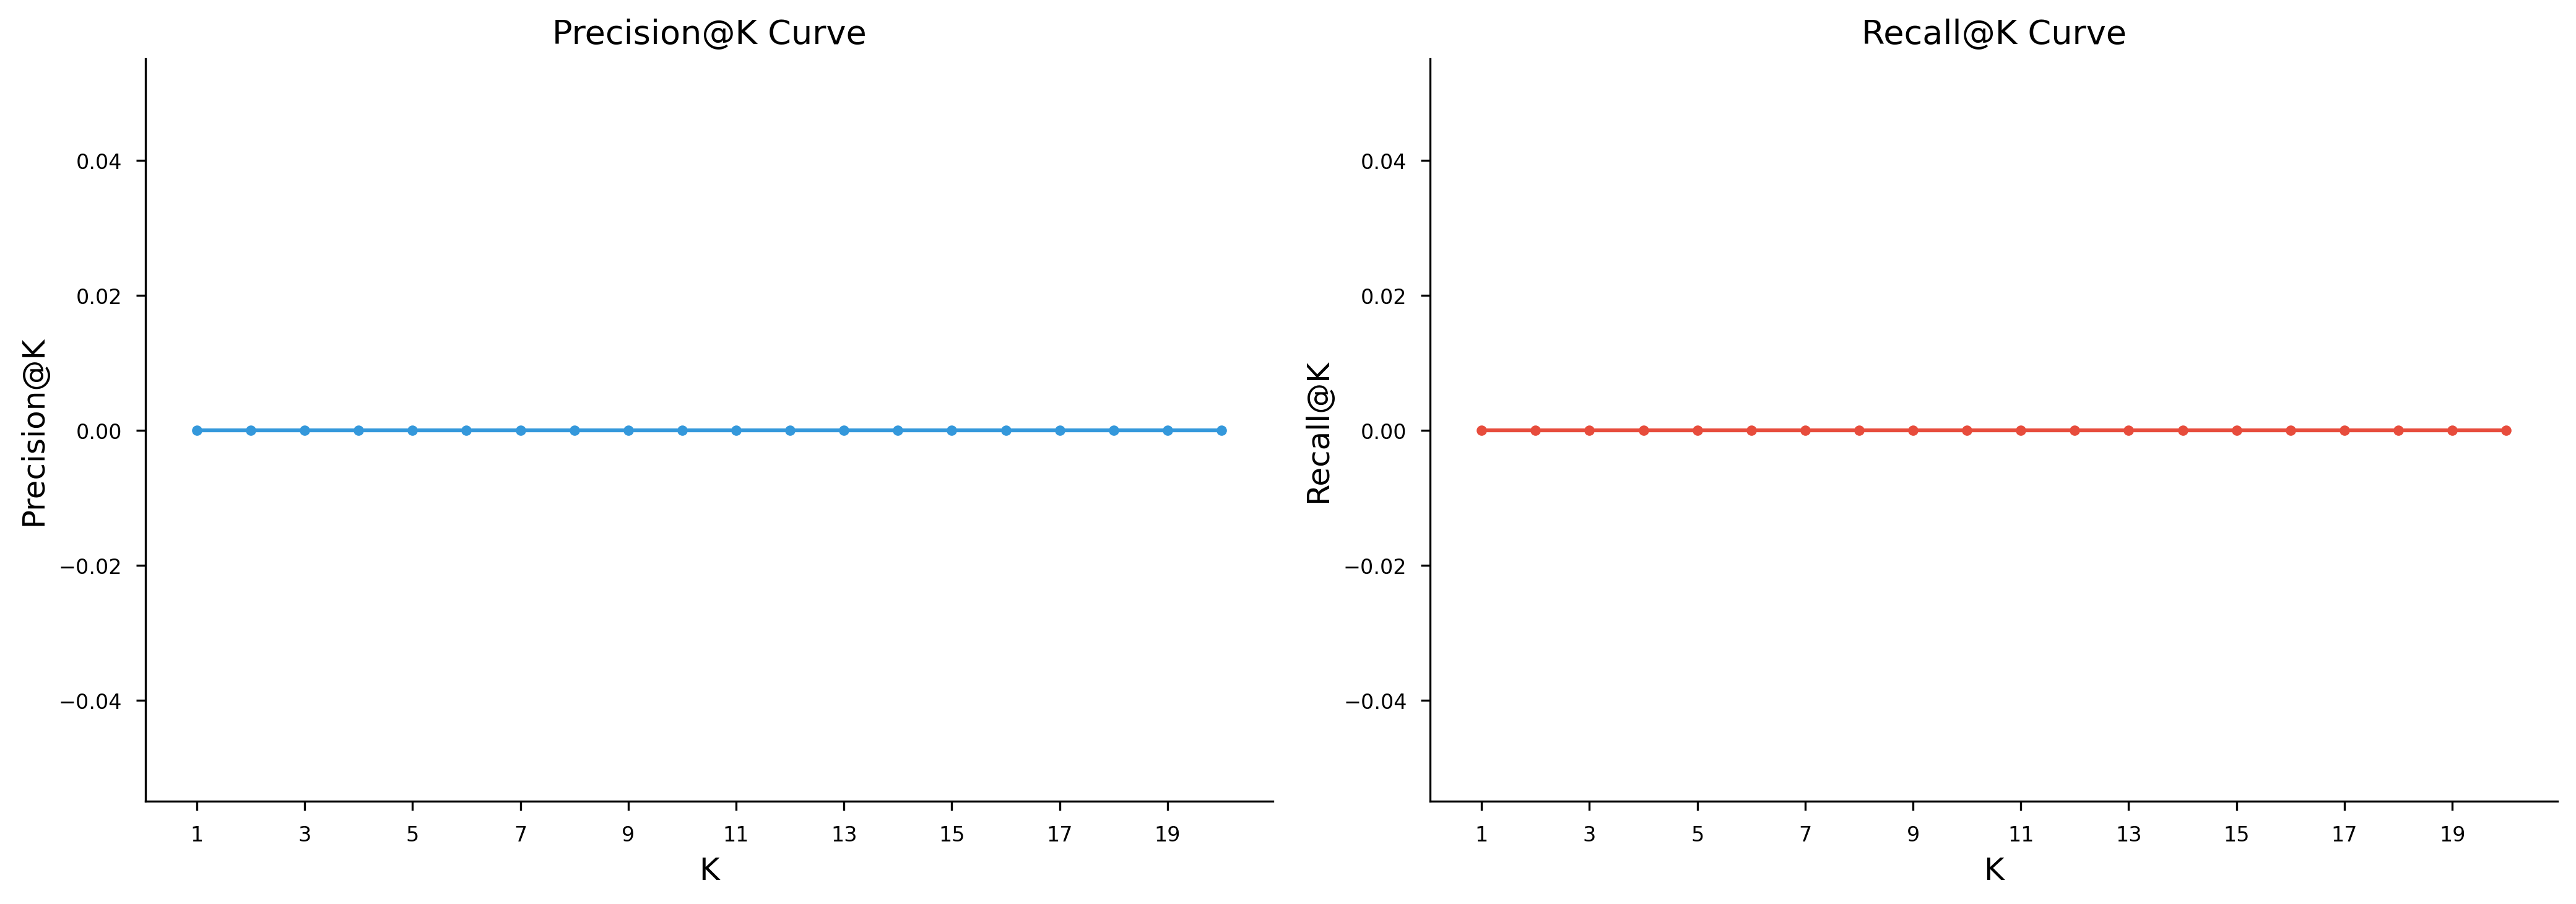

In [6]:
# Compute P@K and R@K for K=1..20 using combined strategy
ks = range(1, 21)
precision_at_k = {k: [] for k in ks}
recall_at_k = {k: [] for k in ks}

for uid in sample_users:
    user_df = interactions[interactions["user_id"] == uid]
    if len(user_df) < 5:
        continue
    gt_questions = set(user_df["question_id"].astype(str).tolist())

    diag_resp = [{"question_id": r["question_id"], "correct": bool(r["correct"])}
                 for _, r in user_df.head(5).iterrows()]
    kg_profile = kg.handle_cold_start(user_id=str(uid), diagnostic={"responses": diag_resp})
    result = rec_agent.recommend(str(uid), kg_profile=kg_profile, n=20)
    rec_ids = [r["item_id"] for r in result.get("items", [])]

    for k in ks:
        top_k = rec_ids[:k]
        hits = len(set(top_k) & gt_questions)
        precision_at_k[k].append(hits / k if k > 0 else 0)
        recall_at_k[k].append(hits / len(gt_questions) if gt_questions else 0)

mean_prec = [np.mean(precision_at_k[k]) for k in ks]
mean_rec = [np.mean(recall_at_k[k]) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, mean_prec, "o-", color="#3498db", markersize=4, linewidth=1.5)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K Curve")
axes[0].set_xticks(list(ks)[::2])

axes[1].plot(ks, mean_rec, "o-", color="#e74c3c", markersize=4, linewidth=1.5)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K Curve")
axes[1].set_xticks(list(ks)[::2])

for ax in axes:
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_precision_recall_at_k.png")
plt.show()

## 5. LambdaMART Training & Feature Importance

In [7]:
# Generate synthetic ranking training data from user interactions
# For each user: candidates from recommend(), labels from actual engagement

train_features_list = []
train_labels_list = []
train_groups = []

for uid in sample_users[:30]:
    user_df = interactions[interactions["user_id"] == uid]
    if len(user_df) < 5:
        continue

    gt_questions = set(user_df["question_id"].astype(str).tolist())
    diag_resp = [{"question_id": r["question_id"], "correct": bool(r["correct"])}
                 for _, r in user_df.head(5).iterrows()]
    kg_profile = kg.handle_cold_start(user_id=str(uid), diagnostic={"responses": diag_resp})

    result = rec_agent.recommend(str(uid), kg_profile=kg_profile, n=20)
    items = result.get("items", [])
    if not items:
        continue

    from agents.recommendation_agent import Rec
    candidates = [
        Rec(item_id=it["item_id"], item_type=it["item_type"],
            score=it["score"], strategy=it["strategy"],
            related_tags=it.get("related_tags", []))
        for it in items
    ]

    feats = rec_agent._build_ranking_features(str(uid), candidates)
    labels = np.array([1.0 if it["item_id"] in gt_questions else 0.0 for it in items])

    train_features_list.append(feats)
    train_labels_list.append(labels)
    train_groups.append(len(items))

if train_features_list:
    X_rank = np.vstack(train_features_list)
    y_rank = np.concatenate(train_labels_list)
    print(f"Ranking data: {X_rank.shape[0]} pairs, {len(train_groups)} groups")

    ranker = rec_agent.train_ranker(X_rank, y_rank, train_groups)
    print("LambdaMART trained.")
else:
    print("Not enough data for ranker training.")

2026-04-02 17:48:34 | mars.agent.knowledge_graph     | INFO    | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


mars.agent.knowledge_graph | Cold-start for u247877: 8 mastered, 3 gaps, 253 recommendations


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00, 72.65it/s]


2026-04-02 17:48:34 | mars.agent.knowledge_graph     | INFO    | Cold-start for u249828: 5 mastered, 6 gaps, 291 recommendations


...

Batches: 100%|██████████| 1/1 [00:00<00:00, 124.38it/s]

Ranking data: 520 pairs, 26 groups


  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init_

mars.agent.recommendation | LambdaMART ranker trained and saved


LambdaMART trained.


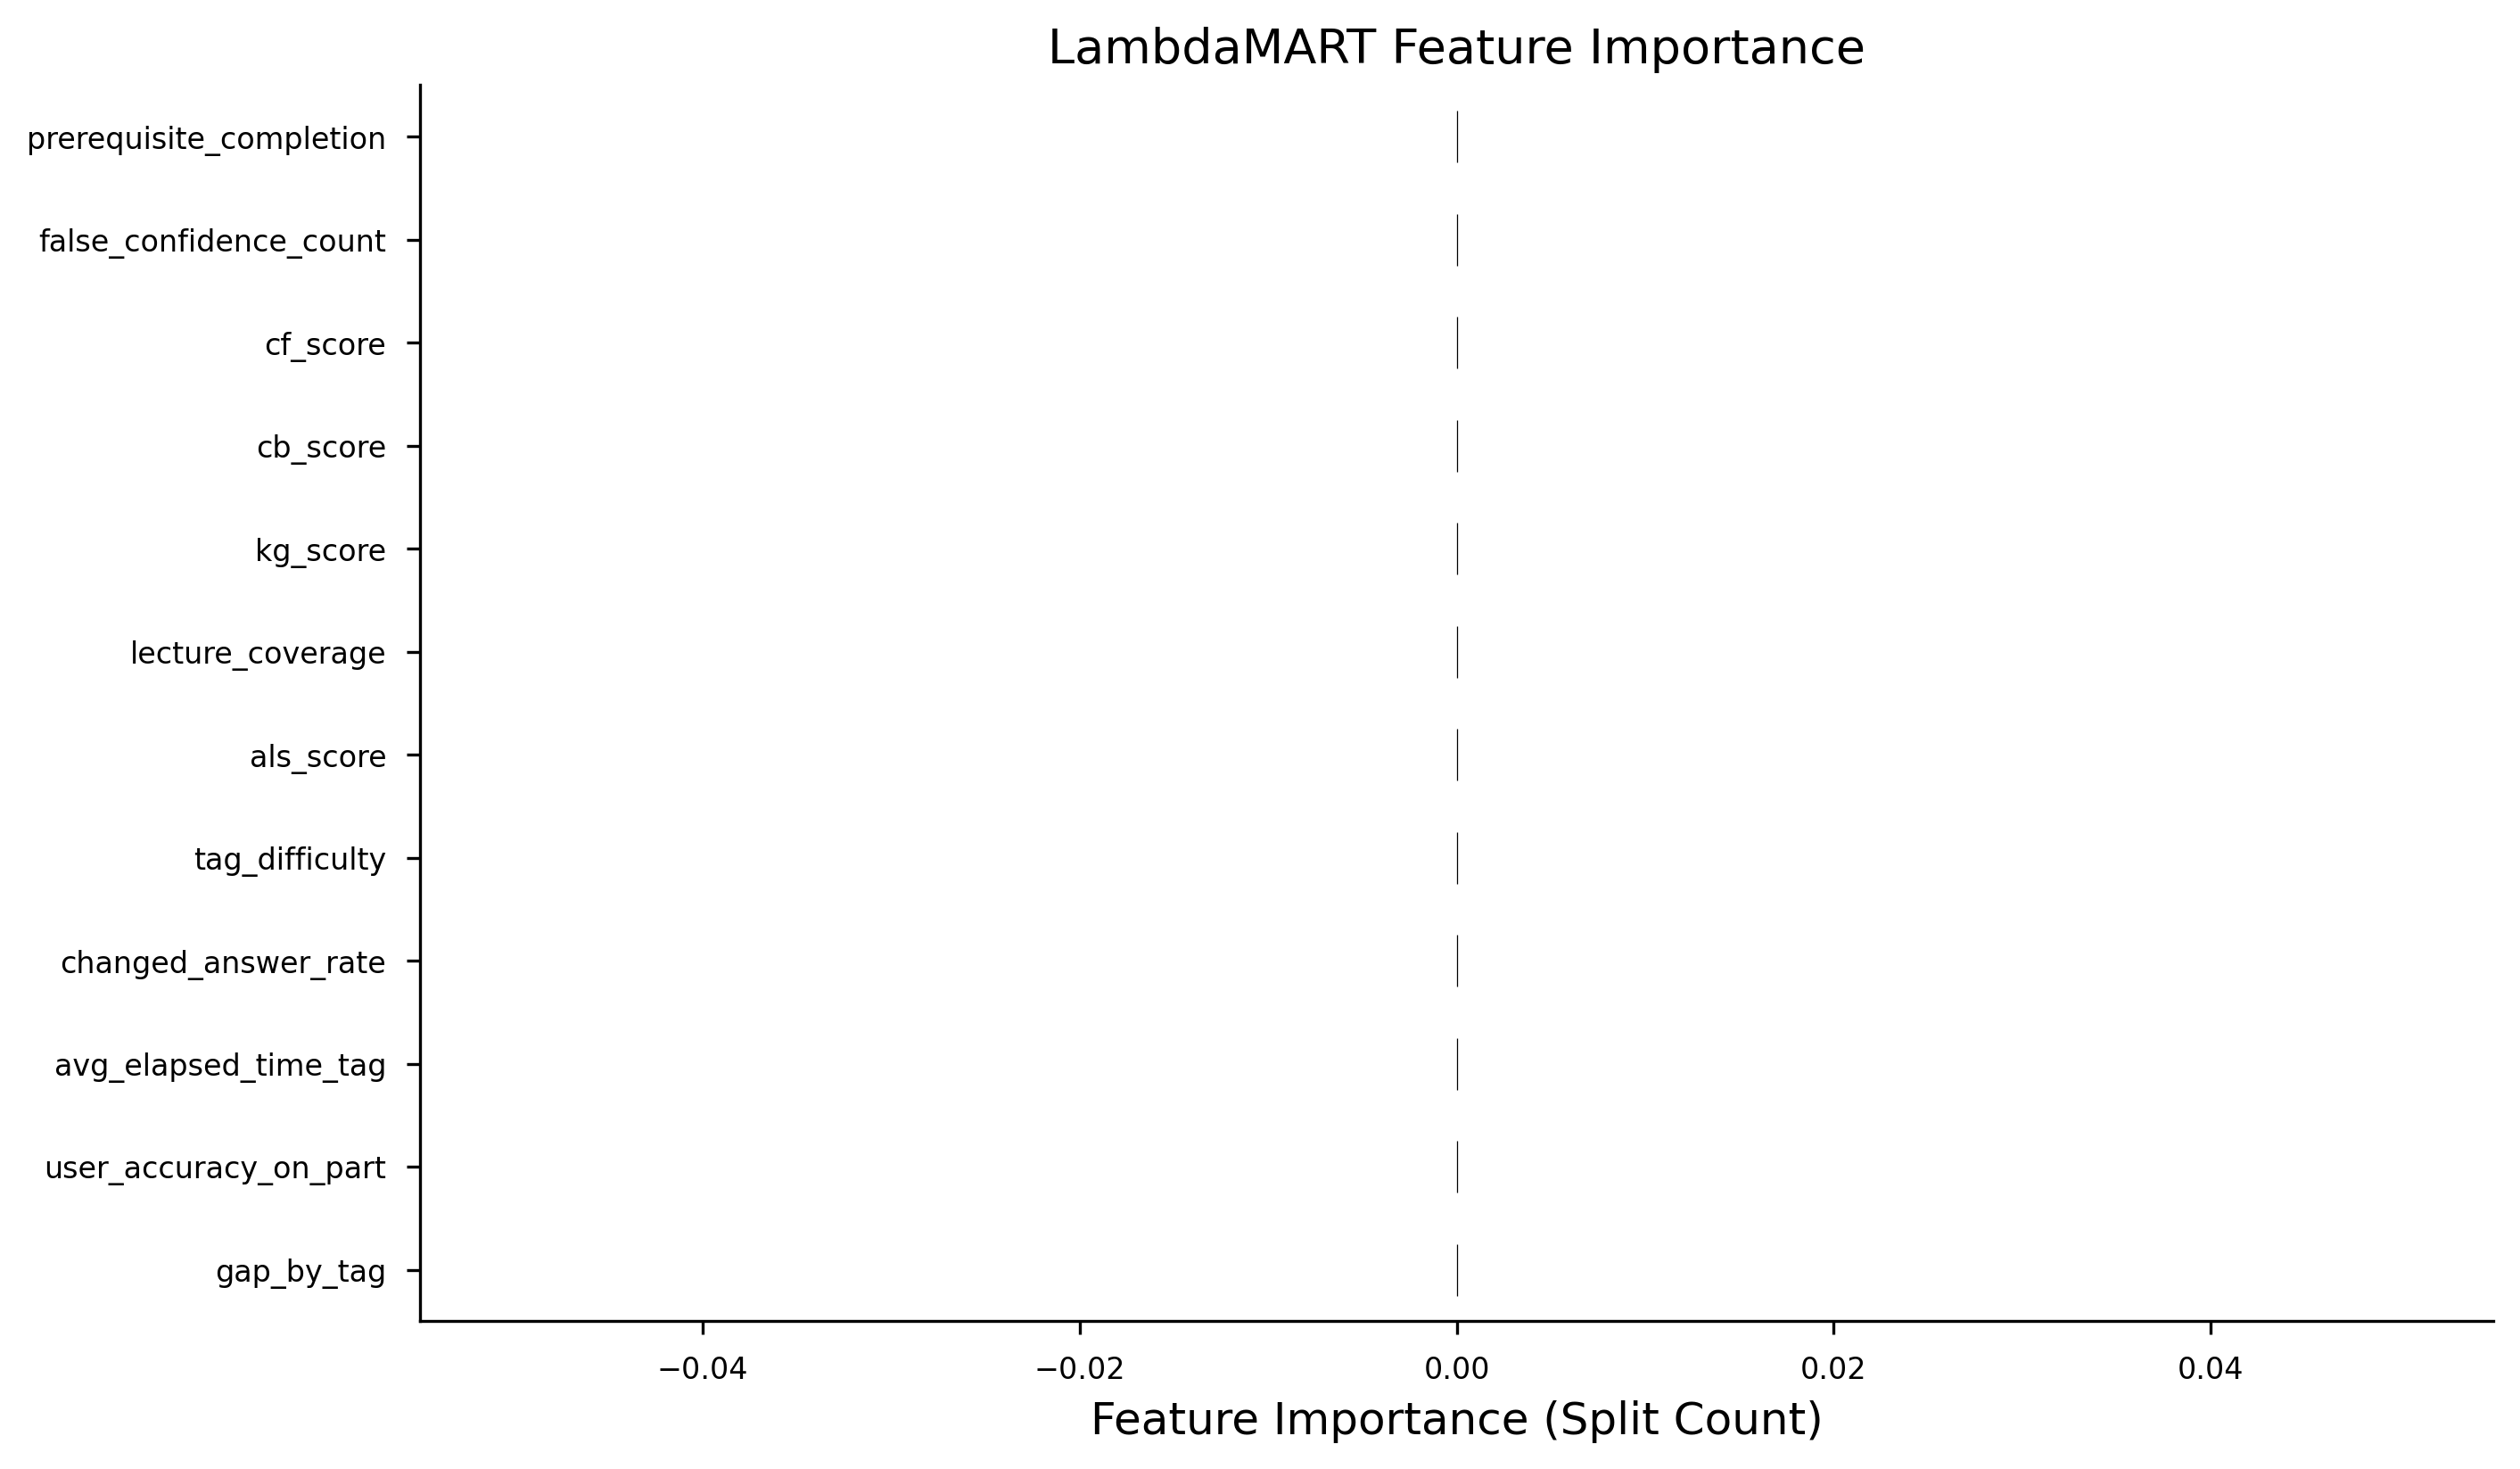

In [8]:
# Feature importance
if rec_agent._ranker is not None:
    imp = rec_agent._ranker.feature_importances_
    imp_series = pd.Series(imp, index=LAMBDAMART_FEATURES).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    imp_series.plot.barh(ax=ax, color="#27ae60", edgecolor="black", linewidth=0.3)
    ax.set_xlabel("Feature Importance (Split Count)")
    ax.set_title("LambdaMART Feature Importance")
    sns.despine()

    fig.savefig(RESULTS_DIR / "fig_lambdamart_importance.png")
    plt.show()
else:
    print("No ranker trained — skipping importance plot.")

In [9]:
print("\n=== Recommendation Analysis Complete ===")
print(f"Strategies: knowledge_based, content_based, collaborative")
print(f"Thompson Sampling: {n_steps} steps simulated")
print(f"Figures saved to: {RESULTS_DIR.resolve()}")


=== Recommendation Analysis Complete ===
Strategies: knowledge_based, content_based, collaborative
Thompson Sampling: 200 steps simulated
Figures saved to: C:\Users\user\Documents\Diser\система\ednet-mars\results
